## Import et init

In [1]:
from src.better_calendar.calendar import Calendar

In [2]:
# Initialisation classique calendrier FR (date_type c'est le type des output de date)
cal = Calendar("FR", "2000-01-01", "2025-12-31", date_type="%Y-%m-%d")
display(cal)

In [3]:
# Default = que les weekend = truc naif sans dépendance
cal = Calendar()

In [4]:
# Multi calendriers
cal = Calendar(["FR", "GB"], "2000-01-01", "2025-12-31", date_type="%Y-%m-%d", multiple_calendars_mode="intersection")

### J'ai eu un pb de uv visiblement je comprends pas pk j'arrive pas à installer pandas_market_calendars

In [2]:
# Exchanges
cal = Calendar("EURONEXT_PARIS", "2000-01-01", "2025-12-31", date_type="%Y-%m-%d")

In [6]:
# Quantlib
cal = Calendar("€STR", "2000-01-01", "2025-12-31", date_type="%Y-%m-%d")

## Basique

In [ ]:
Calendar.is_weekday("2020-01-06")

ValueError: Cannot parse date string '2020-01-06' with format 'date'. Original error: time data '2020-01-06' does not match format 'date'

In [ ]:
# Trucs de base
import datetime as dt
print(cal.is_business("2020-01-06"))
print(cal.is_non_business("2020-01-01"))
print(cal.is_weekend("2020-01-04"))
print(cal.is_weekday("2020-01-06"))
print(cal.business_days("2020-01-01", "2020-01-10"))
print(cal.non_business_days("2020-01-01", "2020-01-10"))
print(cal.semester(dt.date(2020, 3, 15)))
print(cal.week_number(dt.datetime(2020, 3, 15)))
print(cal.week_day("15/03/2020"))
print(cal.days_between("2020-01-01", "2020-01-10"))

False
True
True
True
[datetime.date(2020, 1, 2), datetime.date(2020, 1, 3), datetime.date(2020, 1, 6), datetime.date(2020, 1, 7), datetime.date(2020, 1, 8), datetime.date(2020, 1, 9), datetime.date(2020, 1, 10)]
[datetime.date(2020, 1, 1), datetime.date(2020, 1, 4), datetime.date(2020, 1, 5)]
1
11
7
10


## Offsets

In [14]:
print(cal.offset_business_days("2020-01-01", 5))
print(cal.next_business_day("2020-01-01"))
print(cal.previous_business_day("2020-01-01"))

2020-01-08
2020-01-02
2019-12-31


## Schedule

In [16]:
print(cal.schedule_business(frequency="W", which="first"))
print(cal.schedule_business(frequency="Semester", which=3))
print(cal.schedule_business(frequency="Y", which="last", start_date="2020-01-01", end_date="2022-12-31"))

[datetime.date(2000, 1, 3), datetime.date(2000, 1, 10), datetime.date(2000, 1, 17), datetime.date(2000, 1, 24), datetime.date(2000, 1, 31), datetime.date(2000, 2, 7), datetime.date(2000, 2, 14), datetime.date(2000, 2, 21), datetime.date(2000, 2, 28), datetime.date(2000, 3, 6), datetime.date(2000, 3, 13), datetime.date(2000, 3, 20), datetime.date(2000, 3, 27), datetime.date(2000, 4, 3), datetime.date(2000, 4, 10), datetime.date(2000, 4, 17), datetime.date(2000, 4, 25), datetime.date(2000, 5, 2), datetime.date(2000, 5, 8), datetime.date(2000, 5, 15), datetime.date(2000, 5, 22), datetime.date(2000, 5, 29), datetime.date(2000, 6, 5), datetime.date(2000, 6, 12), datetime.date(2000, 6, 19), datetime.date(2000, 6, 26), datetime.date(2000, 7, 3), datetime.date(2000, 7, 10), datetime.date(2000, 7, 17), datetime.date(2000, 7, 24), datetime.date(2000, 7, 31), datetime.date(2000, 8, 7), datetime.date(2000, 8, 14), datetime.date(2000, 8, 21), datetime.date(2000, 8, 28), datetime.date(2000, 9, 4), d

In [17]:
print(cal.schedule_calendar(frequency="Month", which="first", week_day=2))
print(cal.schedule_calendar(frequency="Y", which="last", week_day=6))

[datetime.date(2000, 1, 4), datetime.date(2000, 2, 1), datetime.date(2000, 3, 7), datetime.date(2000, 4, 4), datetime.date(2000, 5, 2), datetime.date(2000, 6, 6), datetime.date(2000, 7, 4), datetime.date(2000, 8, 1), datetime.date(2000, 9, 5), datetime.date(2000, 10, 3), datetime.date(2000, 11, 7), datetime.date(2000, 12, 5), datetime.date(2001, 1, 2), datetime.date(2001, 2, 6), datetime.date(2001, 3, 6), datetime.date(2001, 4, 3), datetime.date(2001, 5, 1), datetime.date(2001, 6, 5), datetime.date(2001, 7, 3), datetime.date(2001, 8, 7), datetime.date(2001, 9, 4), datetime.date(2001, 10, 2), datetime.date(2001, 11, 6), datetime.date(2001, 12, 4), datetime.date(2002, 1, 1), datetime.date(2002, 2, 5), datetime.date(2002, 3, 5), datetime.date(2002, 4, 2), datetime.date(2002, 5, 7), datetime.date(2002, 6, 4), datetime.date(2002, 7, 2), datetime.date(2002, 8, 6), datetime.date(2002, 9, 3), datetime.date(2002, 10, 1), datetime.date(2002, 11, 5), datetime.date(2002, 12, 3), datetime.date(2003

## Export, plots, summary

In [18]:
# 2,3 stats vite fait on sait jamais
cal.summary()

Calendar code: €STR
Multiple calendars aggregation : union
Date range: 2000-01-01 to 2025-12-31
Total days: 9497
Business days: 6654 (70.06%)
Non-business days: 2843 (29.94%)


In [ ]:
# Exporte dans le format voulu avec les infos statistiques sur le calendrier, très utile en entreprise ça je pense
cal.export("data.xlsx")

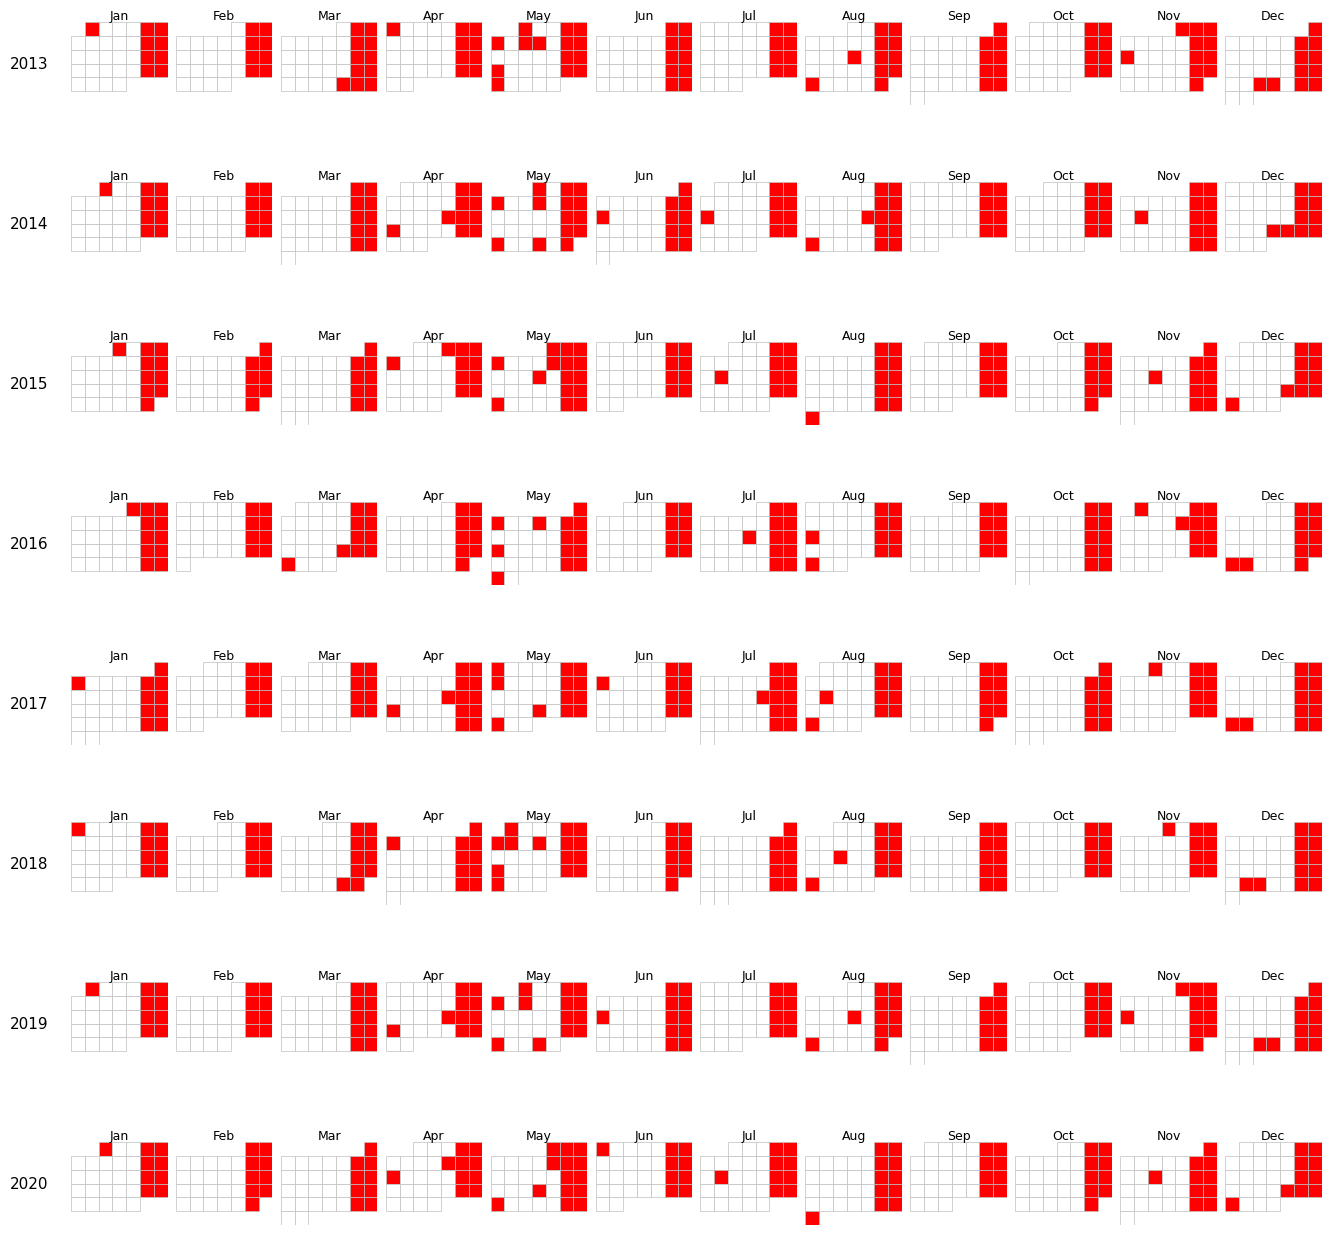

In [ ]:
# Ptit waffle plot des familles
cal.plot("2013-01-01", "2020-12-31")